# DataFrame Methods

In [1]:
import numpy as np 
import pandas as pd

In [70]:
data = {
    "Name": ["Alice", "Bob", "Charlie", "David", "Eva"],
    "Age": [25, 30, 22, 35, 28],
    "City": ["New York", "London", "Paris", "Tokyo", "Berlin"],
    "score": [290,120,340,230,430]
}

data = pd.DataFrame(data)

data

,Name,Age,City,score
0,Alice,25,New York,290
1,Bob,30,London,120
2,Charlie,22,Paris,340
3,David,35,Tokyo,230
4,Eva,28,Berlin,430


In [10]:
ipl = pd.read_csv("ipl.csv")
ipl.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2008,Bangalore,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Kolkata Knight Riders,140,0,BB McCullum,M Chinnaswamy Stadium,Asad Rauf,RE Koertzen,NaN
1,2,2008,Chandigarh,2008-04-19,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,normal,0,Chennai Super Kings,33,0,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",MR Benson,SL Shastri,NaN
2,3,2008,Delhi,2008-04-19,Rajasthan Royals,Delhi Daredevils,Rajasthan Royals,bat,normal,0,Delhi Daredevils,0,9,MF Maharoof,Feroz Shah Kotla,Aleem Dar,GA Pratapkumar,NaN
3,4,2008,Mumbai,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,normal,0,Royal Challengers Bangalore,0,5,MV Boucher,Wankhede Stadium,SJ Davis,DJ Harper,NaN
4,5,2008,Kolkata,2008-04-20,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,normal,0,Kolkata Knight Riders,0,5,DJ Hussey,Eden Gardens,BF Bowden,K Hariharan,NaN


### value_counts

In [6]:
data.value_counts()

Name     Age  City    
Alice    25   New York    1
Bob      30   London      1
Charlie  22   Paris       1
David    35   Tokyo       1
Eva      28   Berlin      1
Name: count, dtype: int64

<Axes: >

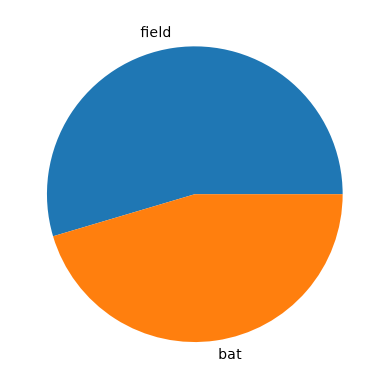

In [26]:
dec = ipl["toss_decision"] 
de = dec.value_counts()
de.plot( kind='pie')

<Axes: >

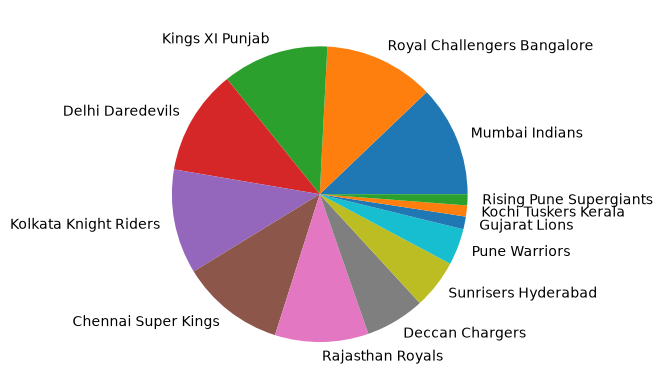

In [36]:
match = (ipl['team1'].value_counts() + ipl['team2'].value_counts())
match.sort_values(ascending=False).plot(kind='pie')

### sort_values()

In [42]:
data.sort_values('Age')

,Name,Age,City
2,Charlie,22,Paris
0,Alice,25,New York
4,Eva,28,Berlin
1,Bob,30,London
3,David,35,Tokyo


In [47]:
data.sort_values("Name", na_position='first')  # handle with missing values

,Name,Age,City
0,Alice,25,New York
1,Bob,30,London
2,Charlie,22,Paris
3,David,35,Tokyo
4,Eva,28,Berlin


In [61]:
ipl.sort_values(['season','city'],ascending=[False , True]).head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
520,521,2016,Bangalore,2016-04-12,Royal Challengers Bangalore,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Royal Challengers Bangalore,45,0,AB de Villiers,M Chinnaswamy Stadium,HDPK Dharmasena,VK Sharma,NaN
527,528,2016,Bangalore,2016-04-17,Royal Challengers Bangalore,Delhi Daredevils,Delhi Daredevils,field,normal,0,Delhi Daredevils,0,7,Q de Kock,M Chinnaswamy Stadium,VA Kulkarni,A Nand Kishore,NaN
546,547,2016,Bangalore,2016-05-02,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,5,AD Russell,M Chinnaswamy Stadium,M Erasmus,S Ravi,NaN
551,552,2016,Bangalore,2016-05-07,Rising Pune Supergiants,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,7,V Kohli,M Chinnaswamy Stadium,CB Gaffaney,BNJ Oxenford,NaN
557,558,2016,Bangalore,2016-05-11,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,6,KH Pandya,M Chinnaswamy Stadium,AY Dandekar,C Shamshuddin,NaN


### Rank

In [78]:
data['rank'] = data['score'].rank(ascending=False)
data.sort_values('rank')

,Name,Age,City,score,rank
4,Eva,28,Berlin,430,1.0
2,Charlie,22,Paris,340,2.0
0,Alice,25,New York,290,3.0
3,David,35,Tokyo,230,4.0
1,Bob,30,London,120,5.0


### sort_index

In [79]:
data.sort_index()

,Name,Age,City,score,rank
0,Alice,25,New York,290,3.0
1,Bob,30,London,120,5.0
2,Charlie,22,Paris,340,2.0
3,David,35,Tokyo,230,4.0
4,Eva,28,Berlin,430,1.0


### set_index

In [84]:
data.set_index("Name",inplace=True) # -> inplace=True to save permanent
data

,Age,City,score,rank
Name,,,,
Alice,25,New York,290,3.0
Bob,30,London,120,5.0
Charlie,22,Paris,340,2.0
David,35,Tokyo,230,4.0
Eva,28,Berlin,430,1.0


### reset_index

In [85]:
data.reset_index()

,Name,Age,City,score,rank
0,Alice,25,New York,290,3.0
1,Bob,30,London,120,5.0
2,Charlie,22,Paris,340,2.0
3,David,35,Tokyo,230,4.0
4,Eva,28,Berlin,430,1.0


### rename 

In [88]:
data.rename(columns={"score":'value'},inplace=True)
data

,Age,City,value,rank
Name,,,,
Alice,25,New York,290,3.0
Bob,30,London,120,5.0
Charlie,22,Paris,340,2.0
David,35,Tokyo,230,4.0
Eva,28,Berlin,430,1.0


In [89]:
# renaming index
data.rename(index={'Alice':'Aliceeee' , 'Bob':'Taki tiki'})

,Age,City,value,rank
Name,,,,
Aliceeee,25,New York,290,3.0
Taki tiki,30,London,120,5.0
Charlie,22,Paris,340,2.0
David,35,Tokyo,230,4.0
Eva,28,Berlin,430,1.0


### unique

In [96]:
ipl['season'].unique()

array([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016])

In [97]:
len(ipl['season'].unique())

9

In [98]:
ipl['season'].nunique()

9

### isnull  notnull hasnans

In [102]:
ipl.isnull()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
572,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
573,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
574,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
575,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True


In [101]:
ipl.notnull()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False
1,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False
2,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False
3,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False
4,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
572,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False
573,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False
574,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False
575,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False


In [107]:
ipl['id'].hasnans   # tells does cloumns has missing values or not

False

In [108]:
### dropna

In [112]:
ipl.dropna()  # it remove whole row if it found anyone missing value in entire row

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3


In [113]:
ipl.dropna(how='all')  # removed entire column as has all missing values done by using how

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2008,Bangalore,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Kolkata Knight Riders,140,0,BB McCullum,M Chinnaswamy Stadium,Asad Rauf,RE Koertzen,NaN
1,2,2008,Chandigarh,2008-04-19,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,normal,0,Chennai Super Kings,33,0,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",MR Benson,SL Shastri,NaN
2,3,2008,Delhi,2008-04-19,Rajasthan Royals,Delhi Daredevils,Rajasthan Royals,bat,normal,0,Delhi Daredevils,0,9,MF Maharoof,Feroz Shah Kotla,Aleem Dar,GA Pratapkumar,NaN
3,4,2008,Mumbai,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,normal,0,Royal Challengers Bangalore,0,5,MV Boucher,Wankhede Stadium,SJ Davis,DJ Harper,NaN
4,5,2008,Kolkata,2008-04-20,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,normal,0,Kolkata Knight Riders,0,5,DJ Hussey,Eden Gardens,BF Bowden,K Hariharan,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
572,573,2016,Raipur,2016-05-22,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN
573,574,2016,Bangalore,2016-05-24,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena,NaN
574,575,2016,Delhi,2016-05-25,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,NaN
575,576,2016,Delhi,2016-05-27,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,4,DA Warner,Feroz Shah Kotla,M Erasmus,CK Nandan,NaN


In [114]:
ipl.dropna(subset=['season','city']) # it remove those rows where missing values found in season or city

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2008,Bangalore,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Kolkata Knight Riders,140,0,BB McCullum,M Chinnaswamy Stadium,Asad Rauf,RE Koertzen,NaN
1,2,2008,Chandigarh,2008-04-19,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,normal,0,Chennai Super Kings,33,0,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",MR Benson,SL Shastri,NaN
2,3,2008,Delhi,2008-04-19,Rajasthan Royals,Delhi Daredevils,Rajasthan Royals,bat,normal,0,Delhi Daredevils,0,9,MF Maharoof,Feroz Shah Kotla,Aleem Dar,GA Pratapkumar,NaN
3,4,2008,Mumbai,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,normal,0,Royal Challengers Bangalore,0,5,MV Boucher,Wankhede Stadium,SJ Davis,DJ Harper,NaN
4,5,2008,Kolkata,2008-04-20,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,normal,0,Kolkata Knight Riders,0,5,DJ Hussey,Eden Gardens,BF Bowden,K Hariharan,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
572,573,2016,Raipur,2016-05-22,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN
573,574,2016,Bangalore,2016-05-24,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena,NaN
574,575,2016,Delhi,2016-05-25,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,NaN
575,576,2016,Delhi,2016-05-27,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,4,DA Warner,Feroz Shah Kotla,M Erasmus,CK Nandan,NaN


### fillna

In [116]:
ipl.fillna('Check')

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2008,Bangalore,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Kolkata Knight Riders,140,0,BB McCullum,M Chinnaswamy Stadium,Asad Rauf,RE Koertzen,Check
1,2,2008,Chandigarh,2008-04-19,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,normal,0,Chennai Super Kings,33,0,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",MR Benson,SL Shastri,Check
2,3,2008,Delhi,2008-04-19,Rajasthan Royals,Delhi Daredevils,Rajasthan Royals,bat,normal,0,Delhi Daredevils,0,9,MF Maharoof,Feroz Shah Kotla,Aleem Dar,GA Pratapkumar,Check
3,4,2008,Mumbai,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,normal,0,Royal Challengers Bangalore,0,5,MV Boucher,Wankhede Stadium,SJ Davis,DJ Harper,Check
4,5,2008,Kolkata,2008-04-20,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,normal,0,Kolkata Knight Riders,0,5,DJ Hussey,Eden Gardens,BF Bowden,K Hariharan,Check
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
572,573,2016,Raipur,2016-05-22,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,Check
573,574,2016,Bangalore,2016-05-24,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena,Check
574,575,2016,Delhi,2016-05-25,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,Check
575,576,2016,Delhi,2016-05-27,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,4,DA Warner,Feroz Shah Kotla,M Erasmus,CK Nandan,Check


In [122]:
data['City'].ffill() # ffill forwardfill and bfill

Name
Alice      New York
Bob          London
Charlie       Paris
David         Tokyo
Eva          Berlin
Name: City, dtype: str

### drop_duplicates

In [128]:
ipl.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
572    False
573    False
574    False
575    False
576    False
Length: 577, dtype: bool

In [131]:
ipl.drop_duplicates(keep='first').head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2008,Bangalore,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Kolkata Knight Riders,140,0,BB McCullum,M Chinnaswamy Stadium,Asad Rauf,RE Koertzen,NaN
1,2,2008,Chandigarh,2008-04-19,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,normal,0,Chennai Super Kings,33,0,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",MR Benson,SL Shastri,NaN
2,3,2008,Delhi,2008-04-19,Rajasthan Royals,Delhi Daredevils,Rajasthan Royals,bat,normal,0,Delhi Daredevils,0,9,MF Maharoof,Feroz Shah Kotla,Aleem Dar,GA Pratapkumar,NaN
3,4,2008,Mumbai,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,normal,0,Royal Challengers Bangalore,0,5,MV Boucher,Wankhede Stadium,SJ Davis,DJ Harper,NaN
4,5,2008,Kolkata,2008-04-20,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,normal,0,Kolkata Knight Riders,0,5,DJ Hussey,Eden Gardens,BF Bowden,K Hariharan,NaN


### drop

In [146]:
# to drop columns
data.drop(columns=['Age'])

,City,value,rank
Name,,,
Alice,New York,290,3.0
Bob,London,120,5.0
Charlie,Paris,340,2.0
David,Tokyo,230,4.0
Eva,Berlin,430,1.0


In [152]:
# how to delete or drop a row 
data.drop(index=['Charlie'])   # if index is in number use integer

,Age,City,value,rank
Name,,,,
Alice,25,New York,290,3.0
Bob,30,London,120,5.0
David,35,Tokyo,230,4.0
Eva,28,Berlin,430,1.0


### apply

In [154]:
def square(x):
    return x*x


data['rank'].apply(square)

Name
Alice       9.0
Bob        25.0
Charlie     4.0
David      16.0
Eva         1.0
Name: rank, dtype: float64

### isin


In [166]:
data[data['City'].isin(['London', 'Tokyo'])]

,Age,City,value,rank
Name,,,,
Bob,30,London,120,5.0
David,35,Tokyo,230,4.0


### corr 

In [162]:
data['rank'].corr(data['value'])  # returns correlation between columns

np.float64(-0.9908386538811731)

### copy

In [164]:
new_data = data.copy()
new_data  # change in new_data wont affect data

,Age,City,value,rank
Name,,,,
Alice,25,New York,290,3.0
Bob,30,London,120,5.0
Charlie,22,Paris,340,2.0
David,35,Tokyo,230,4.0
Eva,28,Berlin,430,1.0


### nlargest nsmallest

In [167]:
data.nlargest(3, 'value')

,Age,City,value,rank
Name,,,,
Eva,28,Berlin,430,1.0
Charlie,22,Paris,340,2.0
Alice,25,New York,290,3.0


In [165]:
data.nsmallest(3, 'value')

,Age,City,value,rank
Name,,,,
Bob,30,London,120,5.0
David,35,Tokyo,230,4.0
Alice,25,New York,290,3.0


### insert

In [174]:
data.insert(1, 'Gender', ['F', 'M', 'M', 'M', 'F'])
data

,Age,Gender,City,value,Status,rank
Name,,,,,,
Alice,25,F,New York,290,Low,3.0
Bob,30,M,London,120,Low,5.0
Charlie,22,M,Paris,340,High,2.0
David,35,M,Tokyo,230,Low,4.0
Eva,28,F,Berlin,430,High,1.0


In [181]:
data.insert(
    3,
    'status',
    data['value'].apply(lambda x: 'High' if x > 300 else 'Low')
)
data

,Age,Gender,City,status,value,rank
Name,,,,,,
Alice,25,F,New York,Low,290,3.0
Bob,30,M,London,Low,120,5.0
Charlie,22,M,Paris,High,340,2.0
David,35,M,Tokyo,Low,230,4.0
Eva,28,F,Berlin,High,430,1.0
